In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [26]:
df = pd.read_csv('formatted_bench.csv')
df

,name,v,gr,max_procs,sec/op
0,ParallelBlocked,3,12,12,0.000024
1,ParallelBlocked,5,12,12,0.000032
2,ParallelBlocked,7,12,12,0.000034
3,ParallelBlocked,10,12,12,0.000044
4,ParallelBlocked,20,12,12,0.000100
...,...,...,...,...,...
94,Sequential,500,1,12,0.190817
95,Sequential,1000,1,12,1.491696
96,Sequential,2000,1,12,12.100815
97,Sequential,5000,1,12,183.509027


In [27]:
seq_df = df[df['name'] == 'Sequential']
seq_df = seq_df.reset_index(drop=True)
seq_df

,name,v,gr,max_procs,sec/op
0,Sequential,3,1,12,6.375000e-07
1,Sequential,5,1,12,8.960000e-07
2,Sequential,7,1,12,1.751000e-06
3,Sequential,10,1,12,4.650000e-06
4,Sequential,20,1,12,2.678300e-05
5,Sequential,50,1,12,3.630520e-04
6,Sequential,100,1,12,2.071641e-03
7,Sequential,500,1,12,1.908175e-01
8,Sequential,1000,1,12,1.491696e+00
9,Sequential,2000,1,12,1.210081e+01


In [28]:
seq_df['mcs/op'] = (seq_df['sec/op'] * (10 ** 6)).round(1).map(lambda x: f'{x:.1f}')
seq_df[['v', 'mcs/op']].set_index('v')

,mcs/op
v,
3,0.6
5,0.9
7,1.8
10,4.6
20,26.8
50,363.1
100,2071.6
500,190817.5
1000,1491696.2


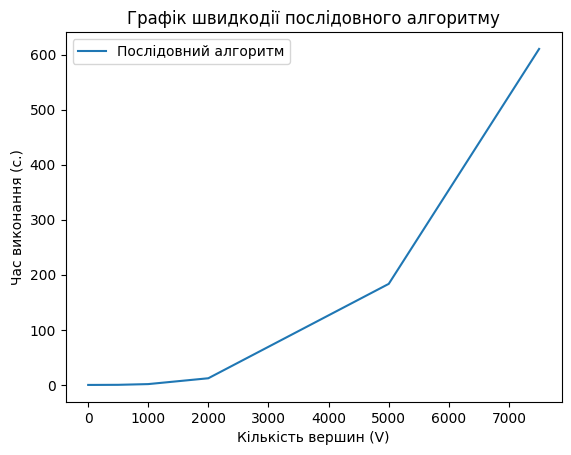

In [29]:
plt.plot(seq_df.v, seq_df['sec/op'], label='Послідовний алгоритм')
plt.legend()
plt.title('Графік швидкодії послідовного алгоритму')
plt.xlabel('Кількість вершин (V)')
plt.ylabel('Час виконання (с.)')
plt.show()

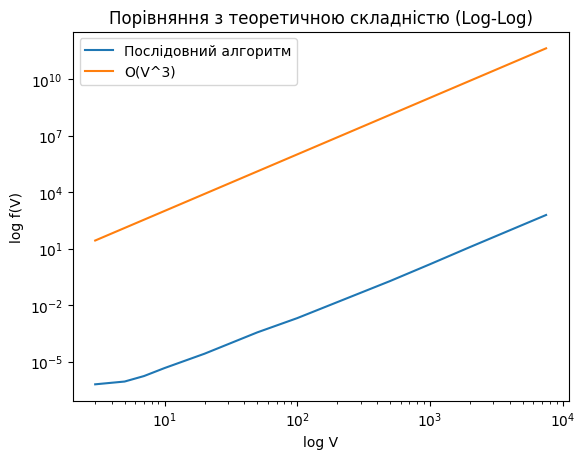

In [30]:
v_3 = seq_df.v ** 3
plt.loglog(seq_df.v, seq_df['sec/op'], label='Послідовний алгоритм')
plt.loglog(seq_df.v, v_3, label='O(V^3)')
plt.legend()
plt.title('Порівняння з теоретичною складністю (Log-Log)')
plt.xlabel('log V')
plt.ylabel('log f(V)')
plt.show()

In [31]:
grouped_df = df.groupby(['name', 'v', 'gr', 'max_procs']).agg({'sec/op': 'mean'})
grouped_df.reset_index(inplace=True)
grouped_df

,name,v,gr,max_procs,sec/op
0,ParallelBlocked,3,12,12,0.000024
1,ParallelBlocked,5,12,12,0.000032
2,ParallelBlocked,7,12,12,0.000034
3,ParallelBlocked,10,12,12,0.000044
4,ParallelBlocked,20,12,12,0.000100
...,...,...,...,...,...
88,Sequential,500,1,12,0.190817
89,Sequential,1000,1,12,1.491696
90,Sequential,2000,1,12,12.100815
91,Sequential,5000,1,12,183.509027


In [32]:
seq_df = grouped_df[grouped_df.name == 'Sequential']
rowed_df = grouped_df[grouped_df.name == 'ParallelRowed']
blocked_df = grouped_df[grouped_df.name == 'ParallelBlocked']
phased_df = grouped_df[grouped_df.name == 'ParallelPhaseBlocked']

In [33]:
seq_time = {}
for _, (v, time) in seq_df[['v', 'sec/op']].iterrows():
    seq_time[v] = time
seq_time

{3.0: 6.375e-07,
 5.0: 8.960000000000001e-07,
 7.0: 1.751e-06,
 10.0: 4.65e-06,
 20.0: 2.6783e-05,
 50.0: 0.000363052,
 100.0: 0.002071641,
 500.0: 0.190817483,
 1000.0: 1.491696198,
 2000.0: 12.100814562,
 5000.0: 183.509026698,
 7500.0: 610.149246413}

In [34]:
grouped_df['acceleration'] = grouped_df.v.map(seq_time) / grouped_df['sec/op']
grouped_df

,name,v,gr,max_procs,sec/op,acceleration
0,ParallelBlocked,3,12,12,0.000024,0.027031
1,ParallelBlocked,5,12,12,0.000032,0.027804
2,ParallelBlocked,7,12,12,0.000034,0.051957
3,ParallelBlocked,10,12,12,0.000044,0.105249
4,ParallelBlocked,20,12,12,0.000100,0.267819
...,...,...,...,...,...,...
88,Sequential,500,1,12,0.190817,1.000000
89,Sequential,1000,1,12,1.491696,1.000000
90,Sequential,2000,1,12,12.100815,1.000000
91,Sequential,5000,1,12,183.509027,1.000000


In [35]:
first_df = grouped_df[ (grouped_df.name == 'Sequential') | ((grouped_df.gr == 12) & (grouped_df.max_procs == 12)) ]
first_df.describe()

,v,gr,max_procs,sec/op,acceleration
count,48.000000,48.000000,48.0,4.800000e+01,48.000000
mean,1349.583333,9.250000,12.0,3.060147e+01,1.610353
std,2345.780838,4.813545,0.0,9.862106e+01,1.621262
min,3.000000,1.000000,12.0,6.375000e-07,0.016070
25%,9.250000,9.250000,12.0,3.821425e-05,0.196398
50%,75.000000,12.000000,12.0,8.711885e-04,1.000000
75%,1250.000000,12.000000,12.0,1.818110e+00,2.669853
max,7500.000000,12.000000,12.0,6.101492e+02,5.100598


In [36]:
seq_df = first_df[first_df.name == 'Sequential']
rowed_df = first_df[first_df.name == 'ParallelRowed']
blocked_df = first_df[first_df.name == 'ParallelBlocked']
phased_df = first_df[first_df.name == 'ParallelPhaseBlocked']

In [37]:
first_df.pivot(index='v', columns='name', values='sec/op')

name,ParallelBlocked,ParallelPhaseBlocked,ParallelRowed,Sequential
v,,,,
3,0.000024,0.000033,0.000040,6.375000e-07
5,0.000032,0.000033,0.000049,8.960000e-07
7,0.000034,0.000030,0.000045,1.751000e-06
10,0.000044,0.000034,0.000058,4.650000e-06
20,0.000100,0.000051,0.000124,2.678300e-05
50,0.000454,0.000234,0.000515,3.630520e-04
100,0.001907,0.001228,0.001876,2.071641e-03
500,0.050226,0.074447,0.047478,1.908175e-01
1000,0.340349,0.547240,0.292455,1.491696e+00


In [38]:
first_df.pivot(index='v', columns='name', values='acceleration')

name,ParallelBlocked,ParallelPhaseBlocked,ParallelRowed,Sequential
v,,,,
3,0.027031,0.019103,0.016070,1.0
5,0.027804,0.027145,0.018314,1.0
7,0.051957,0.058270,0.039103,1.0
10,0.105249,0.137371,0.080637,1.0
20,0.267819,0.523136,0.216074,1.0
50,0.799329,1.553516,0.705177,1.0
100,1.086609,1.687638,1.104281,1.0
500,3.799204,2.563144,4.019064,1.0
1000,4.382837,2.725855,5.100598,1.0


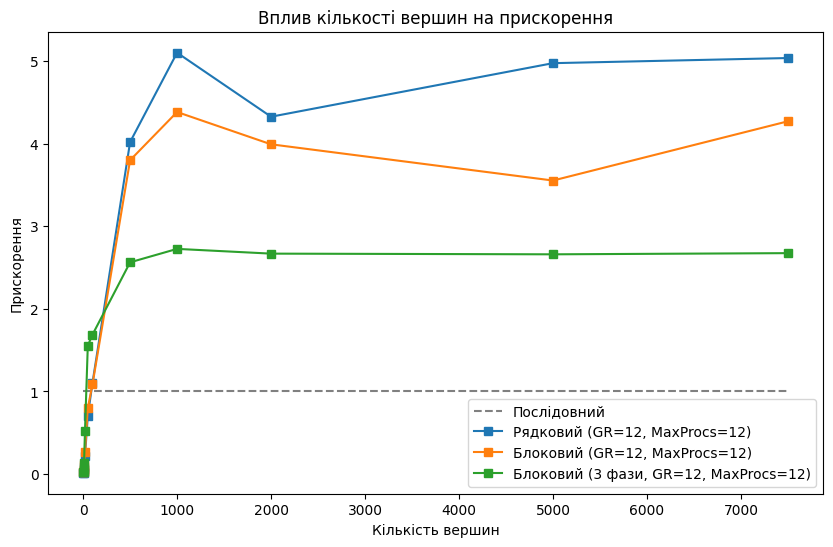

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(seq_df.v, seq_df.acceleration, '--', color='gray', label='Послідовний')
plt.plot(rowed_df.v, rowed_df.acceleration, '-s', label='Рядковий (GR=12, MaxProcs=12)')
plt.plot(blocked_df.v, blocked_df.acceleration, '-s', label='Блоковий (GR=12, MaxProcs=12)')
plt.plot(phased_df.v, phased_df.acceleration, '-s', label='Блоковий (3 фази, GR=12, MaxProcs=12)')
plt.title('Вплив кількості вершин на прискорення')
plt.xlabel('Кількість вершин')
plt.ylabel('Прискорення')
plt.legend()
plt.show()

In [40]:
second_df = grouped_df[ grouped_df.gr == 48 ]
third_df.describe()

NameError: name 'third_df' is not defined

In [ ]:
third_df = third_df.pivot(index='max_procs', columns='name', values='acceleration')
third_df['Sequential'] = 1
third_df

name,ParallelBlocked,ParallelPhaseBlocked,ParallelRowed,Sequential
max_procs,,,,
1,0.971395,0.996711,1.069883,1
2,1.766842,1.813215,1.997585,1
4,3.056813,3.119674,3.531035,1
8,4.211808,3.925603,4.749975,1
12,4.645027,3.949655,5.063004,1
16,4.583822,4.031383,5.043228,1
24,4.579218,4.015168,5.041501,1
32,4.577988,4.037137,5.041141,1


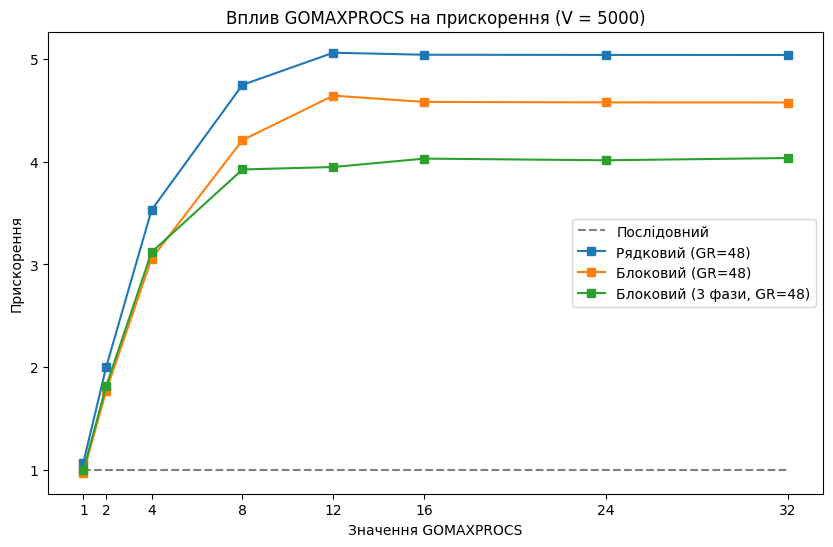

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(second_df.index, second_df['Sequential'], '--', color='gray', label='Послідовний')
plt.plot(second_df.index, second_df['ParallelRowed'], '-s', label='Рядковий (GR=48)')
plt.plot(second_df.index, second_df['ParallelBlocked'], '-s', label='Блоковий (GR=48)')
plt.plot(second_df.index, second_df['ParallelPhaseBlocked'], '-s', label='Блоковий (3 фази, GR=48)')
plt.xticks(second_df.index)
plt.title('Вплив GOMAXPROCS на прискорення (V = 5000)')
plt.xlabel('Значення GOMAXPROCS')
plt.ylabel('Прискорення')
plt.legend()
plt.show()

In [ ]:
third_df = grouped_df[ (grouped_df.max_procs == 12) & (grouped_df.gr != 1) & (grouped_df.v == 5000) ]
third_df.describe()

,v,gr,max_procs,sec/op,acceleration
count,27.0,27.000000,27.0,27.000000,27.000000
mean,5000.0,693.666667,12.0,62.244770,3.688838
std,0.0,1582.110324,0.0,40.761660,1.300644
min,5000.0,2.000000,12.0,34.992972,0.993936
25%,5000.0,9.000000,12.0,38.242513,2.981397
50%,5000.0,24.000000,12.0,45.123993,4.066773
75%,5000.0,144.000000,12.0,62.274767,4.803809
max,5000.0,5000.000000,12.0,184.628639,5.244168


In [ ]:
third_df = third_df.pivot(index='gr', columns='name', values='acceleration')
third_df['Sequential'] = 1.0
third_df

name,ParallelBlocked,ParallelPhaseBlocked,ParallelRowed,Sequential
gr,,,,
2,1.062645,0.993936,1.964914,1.0
4,3.315757,1.290544,3.569133,1.0
9,4.290405,2.654327,4.415487,1.0
12,3.553238,2.660062,4.974172,1.0
24,4.312044,3.302733,4.987841,1.0
48,4.645027,3.949655,5.063004,1.0
144,4.251348,4.303984,5.206260,1.0
1000,3.389412,4.962591,5.244168,1.0
5000,2.193667,4.975504,4.066773,1.0


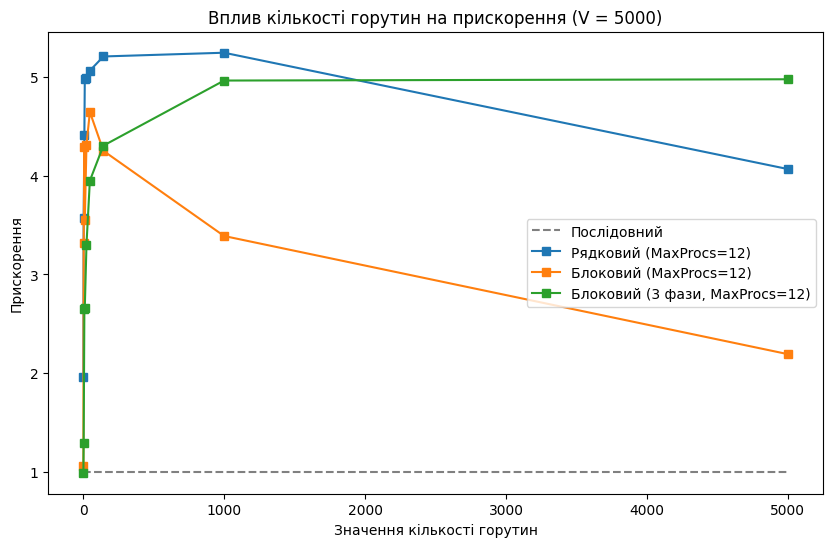

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(third_df.index, third_df['Sequential'], '--', color='gray', label='Послідовний')
plt.plot(third_df.index, third_df['ParallelRowed'], '-s', label='Рядковий (MaxProcs=12)')
plt.plot(third_df.index, third_df['ParallelBlocked'], '-s', label='Блоковий (MaxProcs=12)')
plt.plot(third_df.index, third_df['ParallelPhaseBlocked'], '-s', label='Блоковий (3 фази, MaxProcs=12)')
plt.title('Вплив кількості горутин на прискорення (V = 5000)')
plt.xlabel('Значення кількості горутин')
plt.ylabel('Прискорення')
plt.legend()
plt.show()

In [ ]:
best_df = pd.read_csv('formatted_bench_best.csv')
best_df

,name,max_procs,gr,v,sec/op
0,Blocked,12,9,3,0.000021
1,Blocked,12,9,5,0.000030
2,Blocked,12,9,7,0.000034
3,Blocked,12,9,10,0.000048
4,Blocked,12,9,20,0.000102
5,Blocked,12,9,50,0.000482
6,Blocked,12,9,100,0.001872
7,Blocked,12,9,500,0.050281
8,Blocked,12,9,1000,0.343012
9,Blocked,12,9,2000,3.036862


In [41]:
best_df['acceleration'] = best_df.v.map(seq_time) / best_df['sec/op']
best_df

,name,max_procs,gr,v,sec/op,acceleration
0,Blocked,12,9,3,0.000021,0.030517
1,Blocked,12,9,5,0.000030,0.030187
2,Blocked,12,9,7,0.000034,0.050811
3,Blocked,12,9,10,0.000048,0.096863
4,Blocked,12,9,20,0.000102,0.263687
5,Blocked,12,9,50,0.000482,0.753096
6,Blocked,12,9,100,0.001872,1.106920
7,Blocked,12,9,500,0.050281,3.795007
8,Blocked,12,9,1000,0.343012,4.348822
9,Blocked,12,9,2000,3.036862,3.984645


In [42]:
best_df = best_df.pivot(index='v', columns='name', values='acceleration')
best_df

name,Blocked,PhaseBlocked,Rowed
v,,,
3,0.030517,0.024909,0.035217
5,0.030187,0.027971,0.023392
7,0.050811,0.050842,0.032834
10,0.096863,0.120140,0.050435
20,0.263687,0.336136,0.122442
50,0.753096,0.941417,0.515601
100,1.106920,1.274449,1.080446
500,3.795007,3.089723,3.949026
1000,4.348822,4.314211,5.009031


In [49]:
best_df['Sequential'] = 1.0
best_df

name,Blocked,PhaseBlocked,Rowed,Sequential
v,,,,
3,0.030517,0.024909,0.035217,1.0
5,0.030187,0.027971,0.023392,1.0
7,0.050811,0.050842,0.032834,1.0
10,0.096863,0.120140,0.050435,1.0
20,0.263687,0.336136,0.122442,1.0
50,0.753096,0.941417,0.515601,1.0
100,1.106920,1.274449,1.080446,1.0
500,3.795007,3.089723,3.949026,1.0
1000,4.348822,4.314211,5.009031,1.0


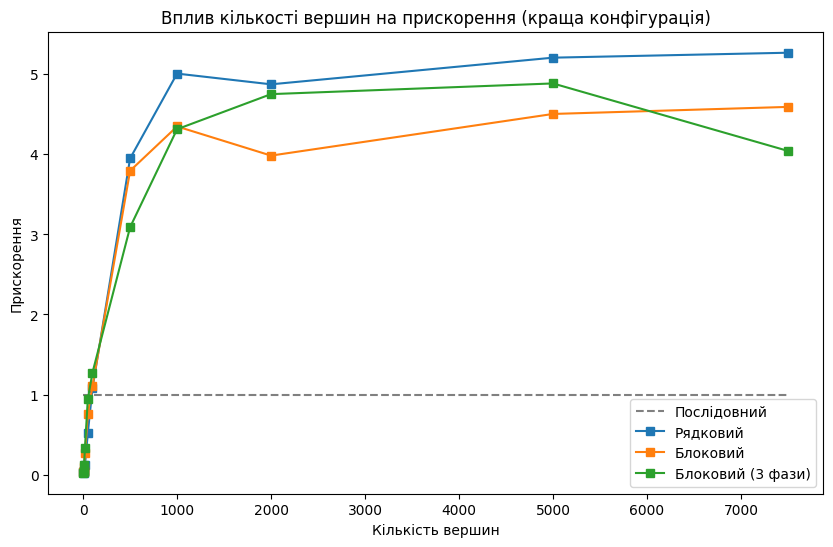

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(best_df.index, best_df['Sequential'], '--', color='gray', label='Послідовний')
plt.plot(best_df.index, best_df['Rowed'], '-s', label='Рядковий')
plt.plot(best_df.index, best_df['Blocked'], '-s', label='Блоковий')
plt.plot(best_df.index, best_df['PhaseBlocked'], '-s', label='Блоковий (3 фази)')
plt.title('Вплив кількості вершин на прискорення (краща конфігурація)')
plt.xlabel('Кількість вершин')
plt.ylabel('Прискорення')
plt.legend()
plt.show()